# 12 · Why balanced training beats naive top-N (588689)

Head-FT on a **balanced** set (equal actives/inactives) beats the paper's default **top-N** selection significantly (AP ×1.27, p=0.028), while **hard-negative** selection significantly *hurts* (AP ×0.70) - even though it contains the *most* actives. So the effect is not simply 'more actives'. This notebook characterizes the two levers that actually drive it:

- **Positive quality** - which actives you train on (top-scored vs scaffold-diverse).
- **Negative hardness** - which inactives you train against (easy/random vs hard high-scoring decoys).

All eval on the held-out rank>1000 set. Per-compound panels use seed 0; aggregate AP/EF use the 5-seed means.

In [1]:

import glob, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
BLK="#000000"; WIN="#1baf7a"; TOP="#2a78d6"; BAD="#d62728"; NEU="#666666"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT="/global/scratch/users/sergiomar10/boltzaff"; R=ROOT+"/results/runs/588689"; V=R+"/ft_inputs_variants"
mlt=pd.read_csv(V+"/ml_table.csv",dtype={"complex_id":str}).set_index("complex_id")
lab=mlt.is_binder.astype(int); noft=mlt.affinity_probability_binary   # No-FT score (for inactive hardness)
STRATS=["top","balanced","actdiv","random","diverse","stratified","hardneg"]
COL={"top":TOP,"balanced":WIN,"actdiv":"#9467bd","random":"#8c564b","diverse":"#17becf","stratified":"#e377c2","hardneg":BAD}
# training-set composition per strategy
comp=[]
for s in STRATS:
    ids=[l.strip() for l in open(V+f"/train_ids_{s}_N300.txt") if l.strip()]
    a=[i for i in ids if lab.get(i,0)==1]; ina=[i for i in ids if lab.get(i,0)==0]
    comp.append(dict(strategy=s, n_act=len(a), n_ina=len(ina),
        ina_hardness=float(noft.reindex(ina).mean()), act_score=float(noft.reindex(a).mean())))
comp=pd.DataFrame(comp).set_index("strategy")
# eval performance from variants_spread.csv
sp=pd.read_csv(ROOT+"/results/analysis/588689/variants_spread.csv")
perf=sp[sp.n_train==300].set_index("strategy")
comp["ap_mean"]=perf.ap_mean; comp["ap_sd"]=perf.ap_sd; comp["ef1_mean"]=perf.ef1_mean
print("training composition + eval AP (held-out rank>1000):")
display(comp.round(3))
# seed-0 eval scores per strategy (for distributions / recovery), + labels on the variant eval set
eval_ids=[l.strip() for l in open(V+"/eval_ids.txt") if l.strip()]
ylab=lab.reindex(eval_ids).fillna(0).astype(int).values
def arm_scores(cond,seed=0):
    fs=sorted(glob.glob(R+f"/headft_variants_scores/{cond}_seed{seed}/chunk_*.csv"))
    if not fs: return None
    f=pd.concat([pd.read_csv(p) for p in fs],ignore_index=True); f["sample_id"]=f.sample_id.astype(str)
    return f.drop_duplicates("sample_id").set_index("sample_id").affinity_probability_binary.reindex(eval_ids)
SC={s:arm_scores(f"{s}_N300") for s in STRATS}


training composition + eval AP (held-out rank>1000):


,n_act,n_ina,ina_hardness,act_score,ap_mean,ap_sd,ef1_mean
strategy,,,,,,,
top,90,210,0.658,0.661,0.155,0.021,29.594
balanced,150,150,0.607,0.639,0.195,0.007,31.977
actdiv,150,150,0.607,0.633,0.169,0.023,30.918
random,58,242,0.606,0.624,0.152,0.015,26.879
diverse,76,224,0.653,0.662,0.163,0.011,28.203
stratified,62,238,0.607,0.631,0.126,0.013,22.245
hardneg,184,116,0.674,0.628,0.108,0.008,25.158


## 1. What each strategy actually feeds the head
Training-set makeup: number of actives, and how *hard* the inactives are (their mean No-FT score - high = decoys that already look like binders). This one figure previews the whole story.

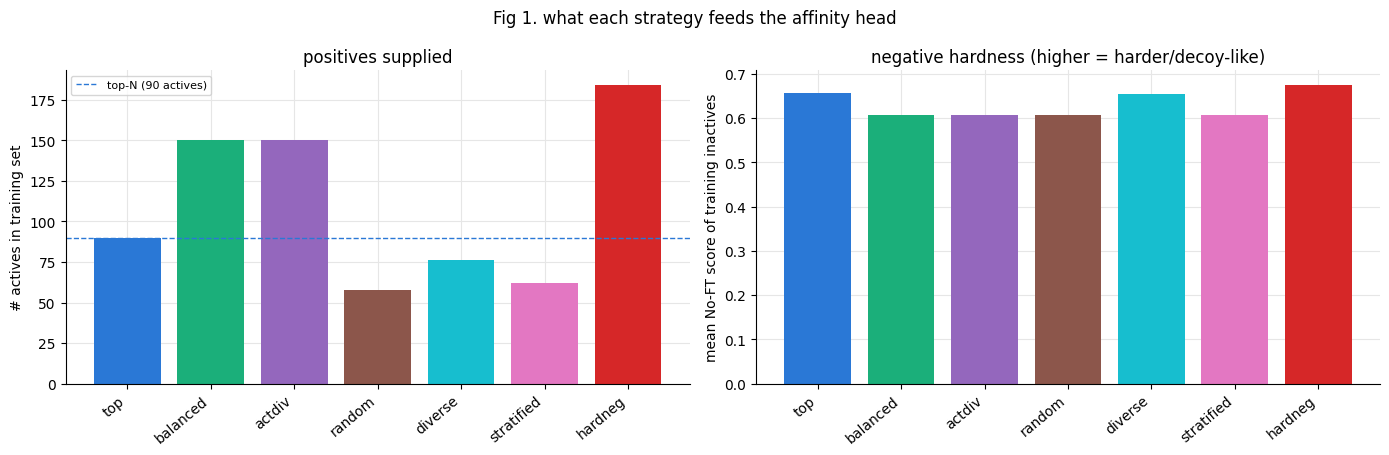

In [2]:
fig,axes=plt.subplots(1,2,figsize=(14,4.6)); x=np.arange(len(STRATS))
c=[COL[s] for s in STRATS]
axes[0].bar(x,comp.loc[STRATS,"n_act"],color=c); axes[0].axhline(90,ls="--",color=TOP,lw=1,label="top-N (90 actives)")
axes[0].set_xticks(x); axes[0].set_xticklabels(STRATS,rotation=40,ha="right"); axes[0].set_ylabel("# actives in training set"); axes[0].set_title("positives supplied"); axes[0].legend(fontsize=8)
axes[1].bar(x,comp.loc[STRATS,"ina_hardness"],color=c); axes[1].set_xticks(x); axes[1].set_xticklabels(STRATS,rotation=40,ha="right")
axes[1].set_ylabel("mean No-FT score of training inactives"); axes[1].set_title("negative hardness (higher = harder/decoy-like)")
fig.suptitle("Fig 1. what each strategy feeds the affinity head",fontsize=12); plt.tight_layout(); plt.show()

## 2. It is not just active count
Eval AP vs number of training actives. If more positives were all that mattered, this would rise monotonically. It does not: **hard-neg has the most actives but the worst AP** (red), and balanced (green) beats top-N with only 60 more actives. Active count is one axis, not the whole answer.

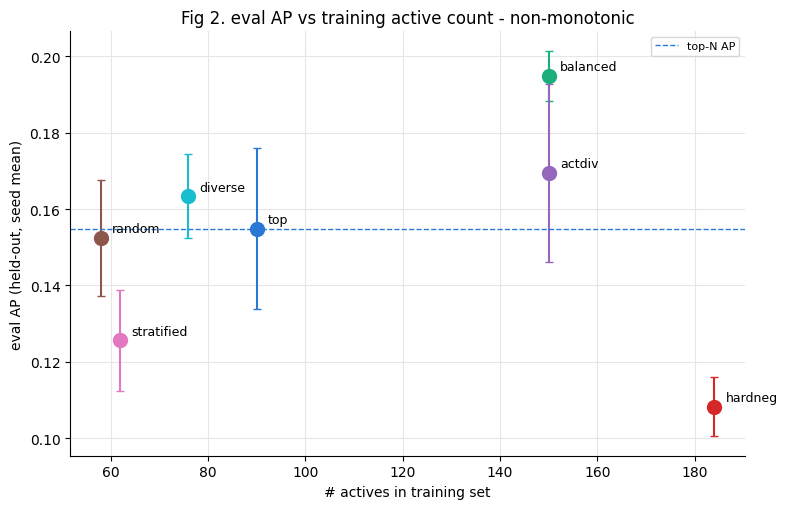

In [3]:
fig,ax=plt.subplots(figsize=(8,5.2))
for s in STRATS:
    ax.errorbar(comp.loc[s,"n_act"],comp.loc[s,"ap_mean"],yerr=comp.loc[s,"ap_sd"],marker="o",ms=10,color=COL[s],capsize=3)
    ax.annotate(s,(comp.loc[s,"n_act"],comp.loc[s,"ap_mean"]),textcoords="offset points",xytext=(8,4),fontsize=9)
ax.axhline(comp.loc["top","ap_mean"],ls="--",color=TOP,lw=1,label="top-N AP")
ax.set_xlabel("# actives in training set"); ax.set_ylabel("eval AP (held-out, seed mean)")
ax.set_title("Fig 2. eval AP vs training active count - non-monotonic"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. The two levers, isolated
Controlled contrasts. **Lever A (positive quality):** balanced vs actdiv - *same* 150 actives + 150 random inactives, differing only in top-scored vs scaffold-diverse actives. **Lever B (negative hardness):** balanced vs hardneg - both active-rich, differing in easy vs hard inactives.

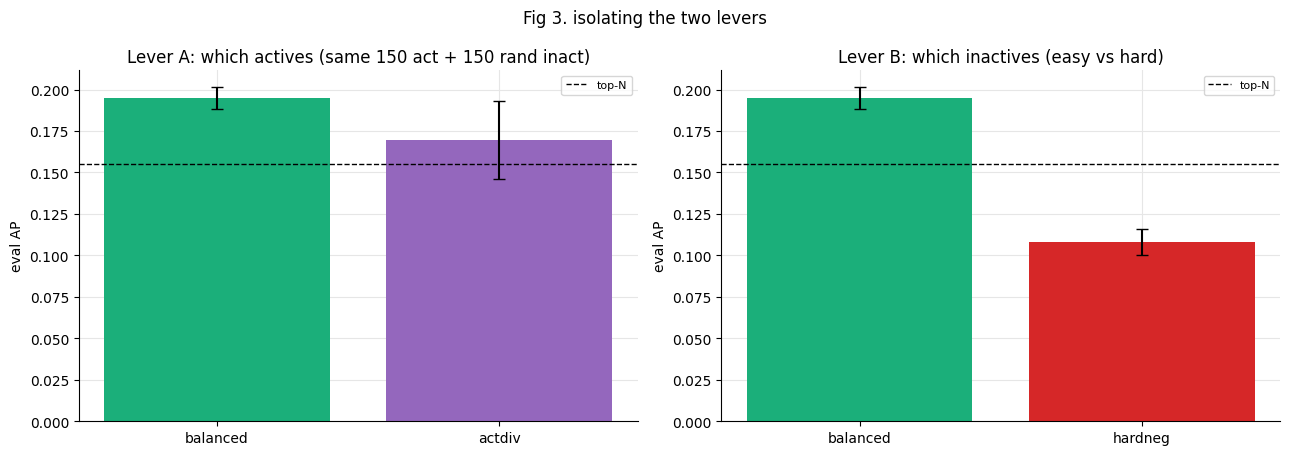

Lever A: balanced 0.195 vs actdiv 0.169 (same 150 actives + 150 random inactives; top-scored vs scaffold-diverse actives)
   paired over seeds: diff +0.0255, t-test p=0.044, Wilcoxon p=0.062, balanced higher in 5 of 5 seeds
Lever B: balanced 0.195 vs hardneg 0.108  (easy negatives > hard negatives)


In [4]:
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
A=["balanced","actdiv"]; B=["balanced","hardneg"]
for ax,grp,ttl in [(axes[0],A,"Lever A: which actives (same 150 act + 150 rand inact)"),(axes[1],B,"Lever B: which inactives (easy vs hard)")]:
    ax.bar(range(len(grp)),[comp.loc[g,"ap_mean"] for g in grp],yerr=[comp.loc[g,"ap_sd"] for g in grp],capsize=4,color=[COL[g] for g in grp])
    ax.set_xticks(range(len(grp))); ax.set_xticklabels(grp); ax.set_ylabel("eval AP"); ax.set_title(ttl)
    ax.axhline(comp.loc["top","ap_mean"],ls="--",color=BLK,lw=1,label="top-N"); ax.legend(fontsize=8)
fig.suptitle("Fig 3. isolating the two levers",fontsize=12); plt.tight_layout(); plt.show()
print("Lever A: balanced %.3f vs actdiv %.3f (same 150 actives + 150 random inactives; top-scored vs scaffold-diverse actives)"%(comp.loc["balanced","ap_mean"],comp.loc["actdiv","ap_mean"]))
ps=pd.read_csv(ROOT+"/results/analysis/588689/variants_per_seed.csv"); bb=ps[ps.cond=="balanced_N300"].set_index("seed").ap.sort_index(); aa=ps[ps.cond=="actdiv_N300"].set_index("seed").ap.sort_index()
print("   paired over seeds: diff %+.4f, t-test p=%.3f, Wilcoxon p=%.3f, balanced higher in %d of %d seeds"%(bb.mean()-aa.mean(),stats.ttest_rel(bb,aa).pvalue,stats.wilcoxon(bb,aa).pvalue,int((bb>aa).sum()),len(bb)))
print("Lever B: balanced %.3f vs hardneg %.3f  (easy negatives > hard negatives)"%(comp.loc["balanced","ap_mean"],comp.loc["hardneg","ap_mean"]))

## 4. Training dynamics - what the head learns
Validation BCE over the 5 epochs (seed 0) per strategy. hard-neg's curve is the tell: pushing hard decoys down drags the whole decision boundary.

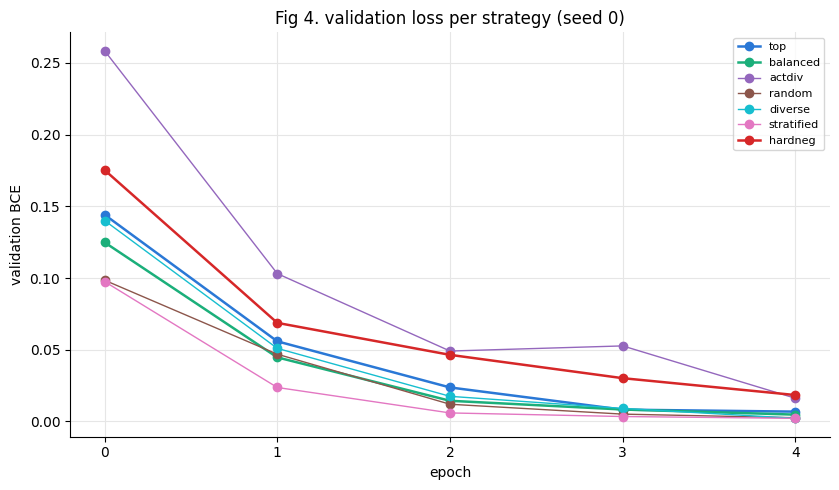

In [5]:
fig,ax=plt.subplots(figsize=(8.5,5))
for s in STRATS:
    ys=[]
    for e in range(5):
        try:
            d=pd.read_csv(R+f"/headft_variants/{s}_N300_seed0/validation_predictions/val_predictions_epoch_{e}.csv")
            y=d.binary_target.values; p=np.clip(d.affinity_probability_binary.values,1e-9,1-1e-9)
            ys.append(-np.mean(y*np.log(p)+(1-y)*np.log(1-p)))
        except Exception: ys.append(np.nan)
    ax.plot(range(5),ys,marker="o",color=COL[s],label=s,lw=1.8 if s in("balanced","hardneg","top") else 1)
ax.set_xlabel("epoch"); ax.set_ylabel("validation BCE"); ax.set_xticks(range(5)); ax.set_title("Fig 4. validation loss per strategy (seed 0)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Eval score separation - actives vs inactives
The point of the head is to separate true actives from decoys on the held-out set. Overlaid score densities per strategy: balanced should push actives right; hard-neg compresses everything (it was trained to distrust high scores).

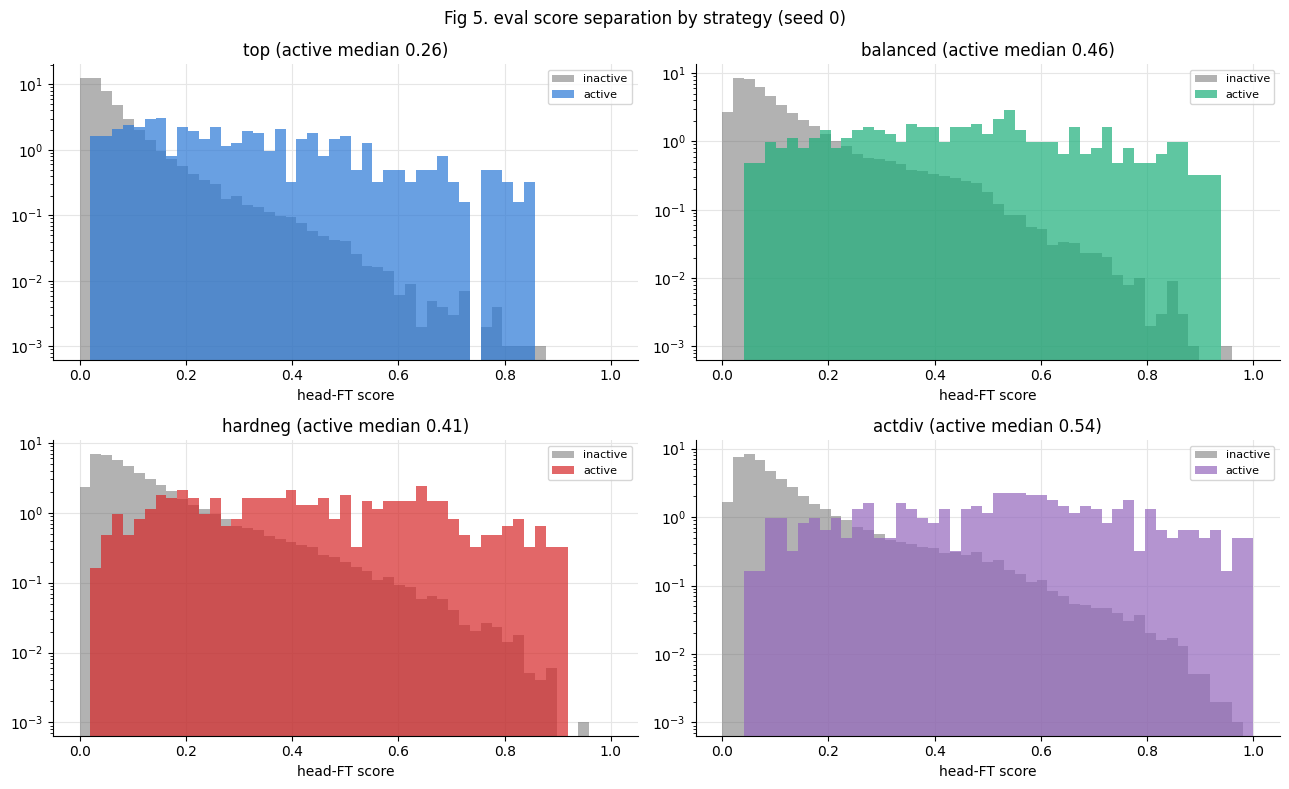

In [6]:
show=["top","balanced","hardneg","actdiv"]
fig,axes=plt.subplots(2,2,figsize=(13,8))
for ax,s in zip(axes.ravel(),show):
    sc=SC[s];
    if sc is None: ax.set_title(s+" (no scores)"); continue
    a=sc.values[ylab==1]; i=sc.values[ylab==0]; bins=np.linspace(0,1,50)
    ax.hist(i,bins=bins,density=True,color=NEU,alpha=0.5,label="inactive")
    ax.hist(a,bins=bins,density=True,color=COL[s],alpha=0.7,label="active")
    ax.set_yscale("log"); ax.set_xlabel("head-FT score"); ax.set_title(f"{s} (active median {np.median(a):.2f})"); ax.legend(fontsize=8)
fig.suptitle("Fig 5. eval score separation by strategy (seed 0)",fontsize=12); plt.tight_layout(); plt.show()

## 6. Mean eval score of the true actives
A one-number version of Fig 5: how high does each strategy score the real actives? hard-neg should sit lowest (it learned to suppress), balanced highest.

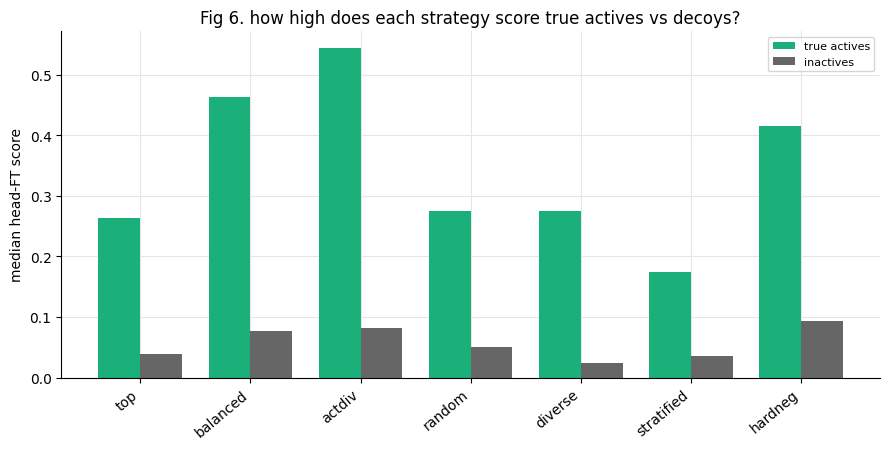

,active_median,inactive_median
strategy,,
top,0.263,0.040
balanced,0.464,0.077
actdiv,0.544,0.082
random,0.276,0.051
diverse,0.275,0.025
stratified,0.175,0.035
hardneg,0.414,0.093


In [7]:
rows=[]
for s in STRATS:
    if SC[s] is None: continue
    rows.append((s, np.median(SC[s].values[ylab==1]), np.median(SC[s].values[ylab==0])))
dd=pd.DataFrame(rows,columns=["strategy","active_median","inactive_median"]).set_index("strategy").loc[[s for s in STRATS if s in [r[0] for r in rows]]]
fig,ax=plt.subplots(figsize=(9,4.6)); x=np.arange(len(dd)); w=0.38
ax.bar(x-w/2,dd.active_median,w,color=WIN,label="true actives"); ax.bar(x+w/2,dd.inactive_median,w,color=NEU,label="inactives")
ax.set_xticks(x); ax.set_xticklabels(dd.index,rotation=40,ha="right"); ax.set_ylabel("median head-FT score"); ax.set_title("Fig 6. how high does each strategy score true actives vs decoys?"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show(); display(dd.round(3))

## 7. Recovered actives in the top 1%
The screening payoff: how many true actives each strategy pulls into the top 1% of the held-out ranking (seed 0). balanced should recover the most.

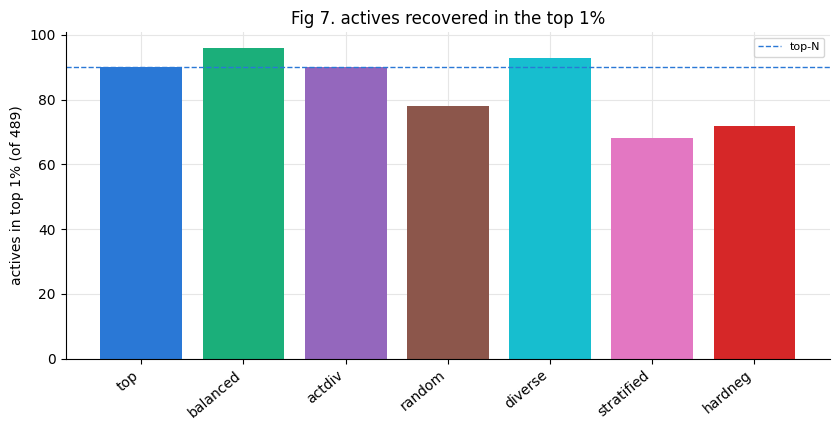

,recovered_actives
strategy,
top,90
balanced,96
actdiv,90
random,78
diverse,93
stratified,68
hardneg,72


In [8]:
k=max(1,int(0.01*len(eval_ids))); rows=[]
for s in STRATS:
    if SC[s] is None: continue
    top=set(SC[s].nlargest(k).index); rec=sum(lab.get(i,0)==1 for i in top); rows.append((s,rec))
rr=pd.DataFrame(rows,columns=["strategy","recovered_actives"]).set_index("strategy")
fig,ax=plt.subplots(figsize=(8.5,4.4)); ax.bar(range(len(rr)),rr.recovered_actives,color=[COL[s] for s in rr.index])
ax.axhline(rr.loc["top","recovered_actives"],ls="--",color=TOP,lw=1,label="top-N")
ax.set_xticks(range(len(rr))); ax.set_xticklabels(rr.index,rotation=40,ha="right"); ax.set_ylabel(f"actives in top 1% (of {k})"); ax.set_title("Fig 7. actives recovered in the top 1%"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show(); display(rr)

## 8. What balanced recovers that top-N misses
Overlap of the top-1% actives found by balanced vs top-N. The compounds unique to balanced are the extra hits the better training buys you.

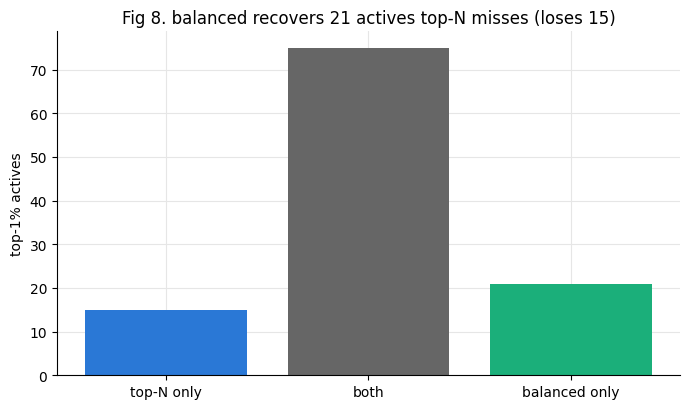

In [9]:
def top_actives(s):
    return set(i for i in SC[s].nlargest(k).index if lab.get(i,0)==1)
ba=top_actives("balanced"); to=top_actives("top")
both=len(ba&to); only_b=len(ba-to); only_t=len(to-ba)
fig,ax=plt.subplots(figsize=(7,4.2))
ax.bar([0,1,2],[only_t,both,only_b],color=[TOP,NEU,WIN]); ax.set_xticks([0,1,2]); ax.set_xticklabels(["top-N only","both","balanced only"])
ax.set_ylabel("top-1% actives"); ax.set_title(f"Fig 8. balanced recovers {only_b} actives top-N misses (loses {only_t})"); plt.tight_layout(); plt.show()

## 9. Does balanced recover more novel actives?
For each recovered active, its max ECFP-Tanimoto to that strategy's *training* actives. Lower = more novel (not an analog of what it was trained on). Shows whether balanced's gain is genuine generalization or just analog recall.

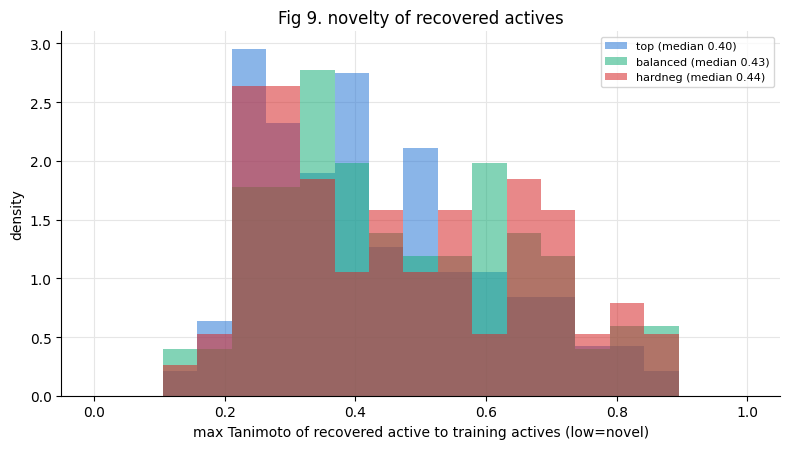

In [10]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem; RDLogger.DisableLog("rdApp.*")
def fp(smi):
    m=Chem.MolFromSmiles(smi) if isinstance(smi,str) else None
    return AllChem.GetMorganFingerprintAsBitVect(m,2,2048) if m else None
def novelty_of_recovered(s):
    tr=[l.strip() for l in open(V+f"/train_ids_{s}_N300.txt")]; tra=[t for t in tr if lab.get(t,0)==1]
    trfp=[x for x in (fp(mlt.smiles.get(t)) for t in tra) if x is not None]
    recs=[i for i in SC[s].nlargest(k).index if lab.get(i,0)==1]
    out=[]
    for i in recs:
        f=fp(mlt.smiles.get(i));
        if f is not None and trfp: out.append(max(DataStructs.BulkTanimotoSimilarity(f,trfp)))
    return out
fig,ax=plt.subplots(figsize=(8,4.6))
for s in ["top","balanced","hardneg"]:
    nv=novelty_of_recovered(s)
    if nv: ax.hist(nv,bins=np.linspace(0,1,20),density=True,color=COL[s],alpha=0.55,label=f"{s} (median {np.median(nv):.2f})")
ax.set_xlabel("max Tanimoto of recovered active to training actives (low=novel)"); ax.set_ylabel("density"); ax.set_title("Fig 9. novelty of recovered actives"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. The hard-negative failure, quantified
Why hard-neg backfires: trained to push high-scoring decoys down, it also demotes true actives (which also score high). Fraction of true actives that hard-neg scores *below* what top-N gives them.

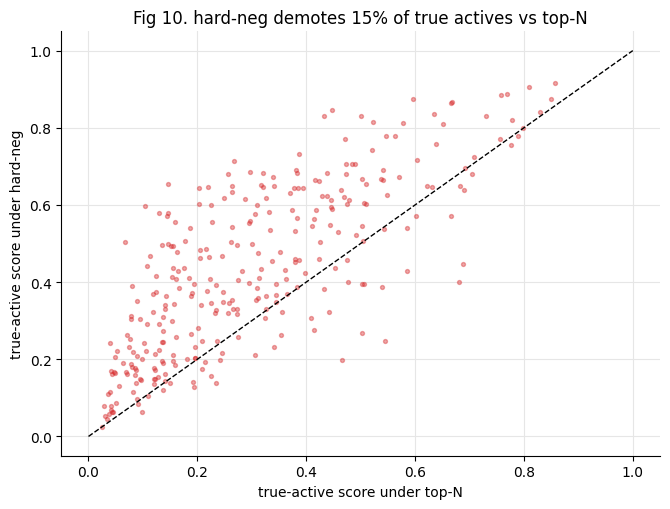

In [11]:
if SC.get("hardneg") is not None:
    a_mask=ylab==1; hn=SC["hardneg"].values[a_mask]; tp=SC["top"].values[a_mask]
    demoted=np.mean(hn<tp)
    fig,ax=plt.subplots(figsize=(6.8,5.2)); ax.scatter(tp,hn,s=8,alpha=0.4,color=BAD); lim=[0,1]
    ax.plot(lim,lim,ls="--",color=BLK,lw=1); ax.set_xlabel("true-active score under top-N"); ax.set_ylabel("true-active score under hard-neg")
    ax.set_title(f"Fig 10. hard-neg demotes {100*demoted:.0f}% of true actives vs top-N"); plt.tight_layout(); plt.show()
else: print("hardneg scores unavailable")

## Conclusion - the recipe and the mechanism

**Recipe:** fine-tune on a **balanced** set - the *top-scored actives* (n/2) plus *easy/random* inactives. On 588689 at N=300 this gives AP x1.27 over the paper's naive top-N (paired p=0.028, uncorrected for the nine strategy comparisons, so promising rather than established). At N=600 the gain shrinks to x1.08 (p=0.053).

**Mechanism - two levers with very different strength (Fig 3):**
1. **Negative hardness (strong).** Easy/random inactives give a clean contrast, and **hard negatives poison it** (Fig 10): trained to push high-scoring decoys down, the head demotes true actives too (they also score high), collapsing enrichment. Hard-neg has the *most* actives yet the *worst* AP; balanced beats it 0.195 to 0.108, in 5 of 5 seeds (paired p<0.0001).
2. **Positive quality (weak).** Top-N training is ~70% inactive, so the head sees few positives. With the same 150 actives and 150 random inactives, top-scored actives (balanced) beat scaffold-diverse actives by 0.026 AP (0.195 vs 0.170, higher in 5 of 5 seeds, paired t-test p=0.044, Wilcoxon p=0.062). That is borderline, not a demonstrated effect.

**Takeaway for the reproduction:** avoiding hard negatives is the firm result. The paper's top-N default is probably not optimal at a small budget, and a balanced set looks better, but this rests on one target and a single comparison with p=0.028. Next: confirm on the other targets once their pipelines finish (same eval_variants machinery).